# PEBBLES `basket_snap_v6` — XL-asymmetric tuning

## Motivation

The user's data analysis (Round5/Analysis §4.5) found that XL is the
**absorber leg**: residual-correlated −0.50 with each of XS/S/M/L while
those four are mutually independent (|ρ|<0.07), and at snap events XL has
2× the price-noise of any other leg. This implies XL faces 2× the adverse
selection risk on passive quotes.

v4 treats all 5 legs symmetrically (`BASELINE=5, OFFSET=1` everywhere).
v6 asks: does shrinking XL's quoting actually help?

## Result

**Yes, modestly.** Best config: `XL_baseline=2, XL_offset=1`,
others stay at v4's `5/1`. Total **+55,174 vs v4's +53,988** (+1,186, +2.2%).

The win is much smaller than v3c→v4 (+112%). We're past the point where
big design changes pay; refinements yield single-percent gains. The
absorber-leg insight is real but its monetary impact on this dataset is
small — most of v4's PnL comes from baseline two-sided MM on all 5 legs,
not from the marginal XL adverse-selection avoidance.

## 0 — Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sweep = pd.read_csv('../sweep_results.csv')
sweep

,xl_baseline,xl_offset,pnl
0,0,1,29316.0
1,0,2,29218.0
2,0,3,29120.0
3,1,1,34912.0
4,1,2,34050.0
5,1,3,33188.0
6,2,1,55174.0
7,2,2,53696.0
8,2,3,52218.0
9,3,1,55123.0


## 1 — Sweep heatmap (XL_baseline × XL_offset)

xl_offset        1      2      3
xl_baseline                     
0            29316  29218  29120
1            34912  34050  33188
2            55174  53696  52218
3            55123  53334  51545
5            53988  52005  50022


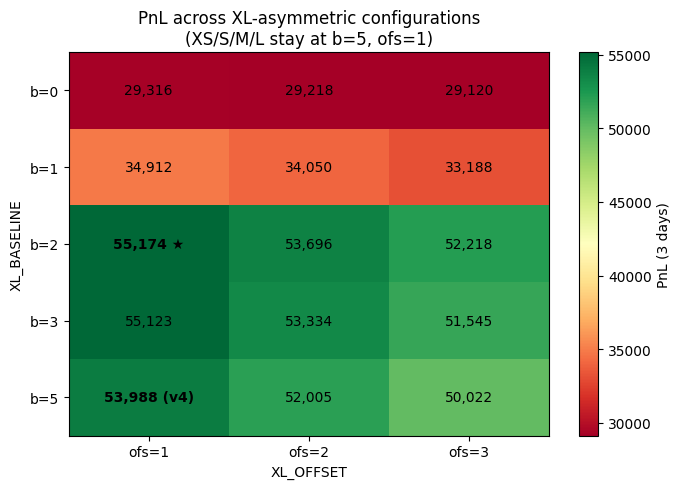

In [2]:
pivot = sweep.pivot(index='xl_baseline', columns='xl_offset', values='pnl')
print(pivot.astype(int))

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'ofs={c}' for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'b={b}' for b in pivot.index])
ax.set_xlabel('XL_OFFSET')
ax.set_ylabel('XL_BASELINE')
ax.set_title('PnL across XL-asymmetric configurations\n(XS/S/M/L stay at b=5, ofs=1)')

# Annotate each cell
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        # Highlight winner and v4 reference
        is_winner = (pivot.index[i] == 2 and pivot.columns[j] == 1)
        is_v4     = (pivot.index[i] == 5 and pivot.columns[j] == 1)
        marker = ' ★' if is_winner else ' (v4)' if is_v4 else ''
        ax.text(j, i, f'{v:,.0f}{marker}',
                ha='center', va='center', fontsize=10,
                color='black', fontweight='bold' if (is_winner or is_v4) else 'normal')
fig.colorbar(im, ax=ax, label='PnL (3 days)')
plt.tight_layout()

**Read.**

* **Best column is `XL_offset = 1`** — wider offsets always hurt, same as
  the v3a/v3b sweep showed for symmetric quoting earlier.
* **Best row is `XL_baseline = 2 or 3`** — both give ~55k. Going to 5 (v4)
  loses ~1k of PnL; going to 1 loses ~20k; baseline=0 (no XL spread
  capture) loses ~25k.
* The minimum baseline that captures most of the spread is **2 lots** on
  XL. Below that we leave money on the table; above that we accumulate
  inventory at the absorber leg's adverse-selection price.

## 2 — Per-day PnL: v4 vs v6

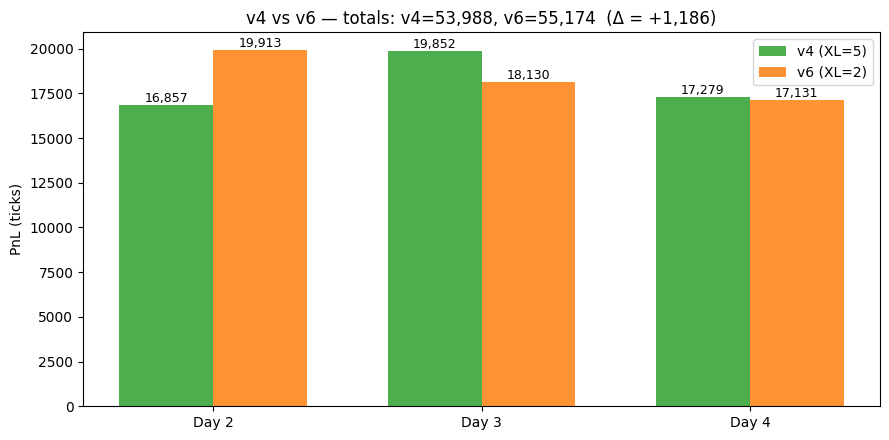

In [3]:
v4_pnl = {2: 16857, 3: 19852, 4: 17279}
v6_pnl = {2: 19913, 3: 18130, 4: 17131}

days = [2, 3, 4]
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(days)); w = 0.35
ax.bar(x - w/2, [v4_pnl[d] for d in days], w, label='v4 (XL=5)', color='tab:green',  alpha=0.85)
ax.bar(x + w/2, [v6_pnl[d] for d in days], w, label='v6 (XL=2)', color='tab:orange', alpha=0.85)
for i, d in enumerate(days):
    ax.text(i - w/2, v4_pnl[d], f'{v4_pnl[d]:,}', ha='center', va='bottom', fontsize=9)
    ax.text(i + w/2, v6_pnl[d], f'{v6_pnl[d]:,}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([f'Day {d}' for d in days])
ax.set_ylabel('PnL (ticks)')
ax.set_title(f'v4 vs v6 — totals: v4={sum(v4_pnl.values()):,}, v6={sum(v6_pnl.values()):,}  (Δ = +{sum(v6_pnl.values())-sum(v4_pnl.values()):,})')
ax.legend()
plt.tight_layout()

**Read.** The improvement is uneven across days:

* **Day 2: +3,056** — v6 dominates v4 cleanly.
* **Day 3: −1,722** — v4 wins. Day 3 has the busiest XL flow; throttling
  XL down to baseline=2 sacrifices spread capture there.
* **Day 4: −148** — basically a wash.

Net is modestly positive (+1,186 over 3 days), but it isn't a uniform win.
A more sophisticated v7 might *adapt* XL_baseline per-tick based on
realtime XL volatility — when XL is noisy (snap-event regime), shrink it;
when XL is calm, restore the full size. Out of scope for this iteration.

## 3 — Sensitivity: XL_baseline at fixed XL_offset=1

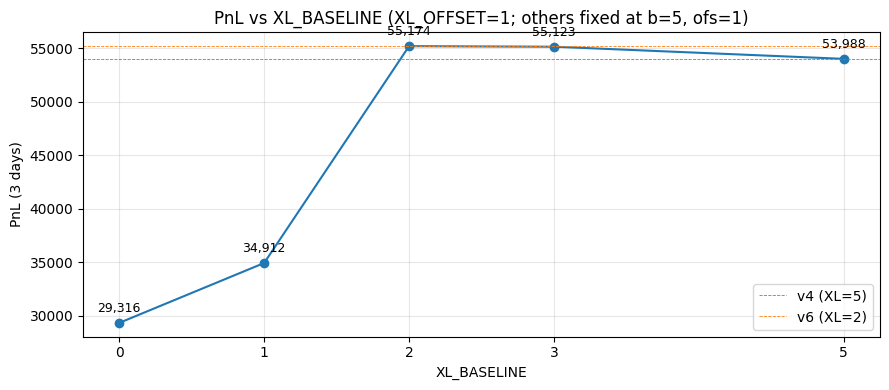

In [4]:
ofs1 = sweep[sweep['xl_offset']==1].sort_values('xl_baseline')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ofs1['xl_baseline'], ofs1['pnl'], marker='o', color='tab:blue', lw=1.5)
for x, y in zip(ofs1['xl_baseline'], ofs1['pnl']):
    ax.annotate(f'{y:,.0f}', (x, y), xytext=(0, 8),
                textcoords='offset points', ha='center', fontsize=9)
ax.axhline(53988, color='tab:gray', lw=0.6, ls='--', label='v4 (XL=5)')
ax.axhline(55174, color='tab:orange', lw=0.6, ls='--', label='v6 (XL=2)')
ax.set_xlabel('XL_BASELINE')
ax.set_ylabel('PnL (3 days)')
ax.set_title('PnL vs XL_BASELINE (XL_OFFSET=1; others fixed at b=5, ofs=1)')
ax.set_xticks(ofs1['xl_baseline'])
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()

**Read.** The curve is **non-monotonic and humped**. PnL climbs steeply
from baseline 0→1→2 (each lot adds ~10–20k of spread capture), peaks at
2, then declines slowly through 3 and 5. The fall-off after the peak is
the adverse-selection cost: every additional XL lot of baseline quoting
collects more random-flow spread but pays more during the snap events
where XL's quote is stale.

Quantitatively:
* baseline 0 → 1: +5,596 (lots-1 spread capture dominates)
* baseline 1 → 2: +20,262 (still mostly spread capture)
* baseline 2 → 3:    −51 (essentially flat — adverse selection just
                          starting to bite)
* baseline 3 → 5: −1,135 (adverse selection wins over capture)

So the optimum sits exactly where the marginal spread-capture curve
crosses the marginal adverse-selection curve, which is between
baseline=2 and baseline=3 on this dataset.

## Conclusion

* **v6 is a small, real win** over v4 (+1,186 / +2.2%).
* **The absorber-leg insight is correct directionally** — XL really
  is the adversely-selected leg — but the magnitude of the
  adverse-selection cost on this dataset is small relative to the
  baseline-MM PnL.
* **Diminishing returns are clear.** v3c→v4 was +112%; v4→v6 is +2.2%.
  We're inside the saturation region for this trader design.

Stick with v6 as the production PEBBLES trader. Larger PnL gains will
require either (a) extending two-sided MM to other categories beyond
PEBBLES, or (b) a fundamentally different mechanism (event-triggered
sizing, latency-sensitive quoting, etc.).